In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad, trapezoid, cumulative_trapezoid, solve_ivp
from scipy.interpolate import interp1d, CubicSpline
from scipy.special import factorial, gamma

# Cinética de Procesos (Sesión 05)

<img src="figures/LogoCinvestav.png" style="height:100px" title="Cinvestav">

**CINVESTAV Unidad Saltillo**

**Programa de Maestría en Ciencias en Ingeniería Metalúrgica**

Dr. Edgar Ivan Castro Cedeño

Contacto:
[edgar.castro@cinvestav.mx](mailto:edgar.castro@cinvestav.mx)

# 5. Modelos de un parámetro

## 5.1 Modelo de tanques en serie

Debajo se presenta la ecuación RTD para $n$ tanques de igual tamaño en serie. Con un solo tanque, la curva RTD corresponde a la de un reactor CSTR, y cuando el número de tanques es muy grande, la curva RTD se aproxima a la de un reactor PFR.

$$E(t) = \frac{\displaystyle n(n\Theta)^{n-1}}{\displaystyle \tau\left(n-1\right)!} \exp \left(-n {\Theta}\right)$$

$$E(\Theta) = \tau E(t) = \frac{\displaystyle n(n\Theta)^{n-1}}{\displaystyle \left(n-1\right)!} \exp \left(-n {\Theta}\right)$$

$$\Theta = \frac{t}{\tau}$$

In [55]:
def Ncstr(t, tau, n):
    Th = t/tau                     #Γ(n+1)=n!
    return 1/tau * n*(n*Th)**(n-1)/gamma(n) * np.exp(-n*Th)

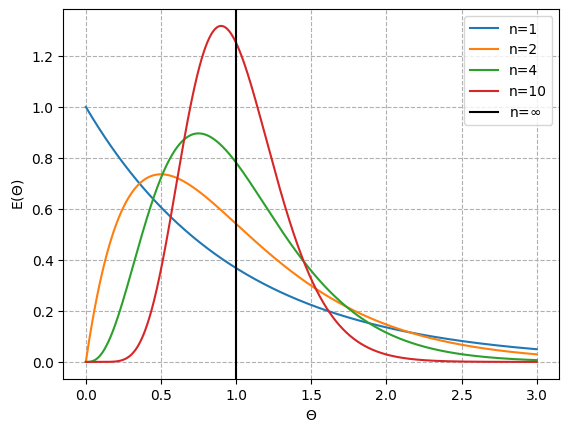

In [64]:
t = np.linspace(0, 3, 1001)
tau = 1.0

fig, ax = plt.subplots()
ntanks = [1, 2, 4, 10]
for n in ntanks:
    ax.plot(t, Ncstr(t, tau, n), label=f"n={n}")
ax.axvline(1, c='k', label=r"n=$\infty$")
ax.set_xlabel(r"$\Theta$")
ax.set_ylabel(r"E($\Theta$)")
ax.legend()
ax.grid(ls='--')
plt.show()

## 4.4

In [70]:
### Datos
t = np.array([0, 0.5, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 14]) # min
C = np.array([0, 0.6, 1.4, 5, 8, 10, 8, 6, 4, 3, 2.2, 1.5, 0.6, 0]) # g/m3

C0 = 1
k = 0.25 # 1/min
order=1

#
d = 0.1 #m
l = 6.36 # m
V =  np.pi*(d/2)**2 * l * 1e3 #dm3
print(f"V={V:.2f} dm3")

V=49.95 dm3


In [69]:
# Curva C(t)
Ci = interp1d(t, C, kind='linear') # linear
# Curva E(t)
Ei = interp1d(t, Ci(t)/trapezoid(Ci(t),t)) # linear
# Curva F(t)
Fi = interp1d(t, cumulative_trapezoid(Ei(t), t, initial=0)) # linear

# Moments (linear interpolation)
tmi = trapezoid(t*Ei(t), t) # mean residence time
s2i = trapezoid((t-tmi)**2 * Ei(t), t) # variance
s3i = trapezoid(1/(s2i**3)*(t-tmi)**3 * Ei(t), t) # skewness

print(f"tm   [min]: {tmi:8.2f}")
print(f"σ    [min]: {np.sqrt(s2i):8.2f}")
print(f"σ2 [min^2]: {s2i:8.2f}")
print(f"s3 [min^3]: {s3i:8.2f}")

tm   [min]:     5.10
σ    [min]:     2.46
σ2 [min^2]:     6.05
s3 [min^3]:     0.05


In [71]:
Q = V/tau
print(f"Q={Q:.2f} dm3/min")

Q=25.00 dm3/min
